# Real Estate — Regression Modeling & Tuning

The modeling step of the regression walkthrough: predict a home's **sale price** — a continuous
target. Rather than judge each model family on a single hand-picked configuration, we give every
family **its own grid search** and compare the best-tuned version of each, head to head, on the
same train/test split.

## Learning objectives

- Run a `GridSearchCV` for several regression model families on the same data.
- Explain why a **dimensionless** metric like $R^2$ is the wrong thing to select a price model on,
  and tune on **MAE** instead.
- Score every tuned model with three complementary metrics — MAE, MAPE, and $R^2$ — and collect
  them into a single comparison table.
- Read predicted-vs-actual diagnostics for each tuned model to judge fit and over/under-fitting.

## Background

This notebook assumes the preprocessed real-estate table from `U1_RealEstate-2_Preprocess`, the
model families and train/test split from `U1-3_Regression-1_ModelCompare`, and `GridSearchCV` with
$K$-fold cross-validation from `U1-3_Regression-4_GridSearchCV`.

The three metrics reported throughout — MAE, MAPE, and $R^2$ — are defined in section 3, alongside
the argument for which of them should choose the model.

**Prerequisites:** `U1_RealEstate-2_Preprocess` (the dataset),
`U1-3_Regression-4_GridSearchCV` (grid search + cross-validation),
`U1-3_Regression-1_ModelCompare` (the model families)

## This notebook covers

1. Load the preprocessed data.
2. Prepare the features (scale) and split train/test.
3. Grid-search each model family and collect every metric into one table.
4. Compare the tuned models.
5. Predicted-vs-actual diagnostics for each tuned model.

**Dataset:** `Real Estate Data_preprocessed.csv` — the cleaned, encoded output of
`U1_RealEstate-2_Preprocess` (1,256 homes; `Sale Price` is the target).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers


## 1. Load the preprocessed data

Notebook 2 (`U1_RealEstate-2_Preprocess`) already cleaned this dataset, engineered the features,
and encoded every column — saving the finished result to `Real Estate Data_preprocessed.csv`. We
load that file and go straight to modeling.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

# Load the fully preprocessed dataset saved by notebook 2.
df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data_preprocessed.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Columns: 195 entries, Type to Sale Condition_Sale between family members
dtypes: float64(4), int64(167), object(24)
memory usage: 1.9+ MB


,Type,Zoning Class,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,Overall Qual,Overall Cond,Year,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Heating Qual,Central Air,Electrical,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Year Garage,Garage Finish,Garage Cars,Garage Qual,Garage Cond,Paved Drive,Pool Qual,Fence,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,196.0,3,2,Poured Contrete,3,2,No Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,8,Typical Functionality,0,0,Attached to home,2003.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,0.0,2,2,Cinder Block,3,2,Good Exposure,Avg Living Quarters,4,1,Standard Circuit Breakers & Romex,0,1,2,0,3,1,2,6,Typical Functionality,1,2,Attached to home,1976.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,162.0,3,2,Poured Contrete,3,2,Min Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,6,Typical Functionality,1,2,Attached to home,2001.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,Slightly irregular,Level,Corner lot,Gentle,

## 2. Prepare the data for modeling

### 2.1 Features and target

The target is the continuous `Sale Price`; every other column is a feature.

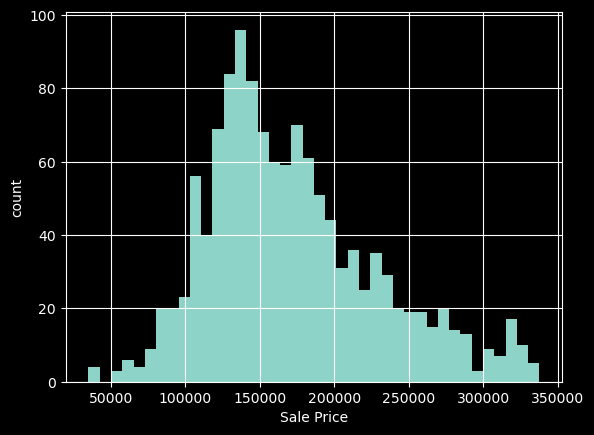

In [3]:
label = 'Sale Price'

# The preprocessed file now also carries the original string columns alongside their dummy
# encodings, so keep only the numeric columns (dummies + numeric features) for modeling.
X_raw = df.drop(columns=[label]).select_dtypes(exclude='object')
y = df[label].copy()

y.hist(bins=40)
plt.xlabel('Sale Price')
plt.ylabel('count');

### 2.2 Scale the features

The feature matrix is already fully numeric — ordinal-encoded qualities + dummies, with the raw
string columns dropped above. We scale the whole thing: tree models don't care, but KNN and linear
models are very sensitive to feature ranges — and we are about to compare all three families on
equal footing.

In [4]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X = pd.DataFrame(
    std_scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

X.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Basement Height,Basement Cond,Heating Qual,Central Air,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Fireplaces,Fireplce Qual,Year Garage,Garage Cars,Garage Qual,Garage Cond,Pool Qual,Floors,Indoor Area,Outdoor Area,Basement Finished Area Fraction,Type_1 STORY PUD,Type_1-1/2 STORY ALL AGES,Type_1-STORY 1945 & OLDER,Type_1-STORY PUD,Type_2 FAMILY CONVERSION,Type_2-1/2 STORY ALL AGES,Type_2-STORY 1945 & OLDER,Type_2-STORY 1946 & NEWER,Type_2-STORY PUD,Type_DUPLEX,Type_SPLIT FOYER,Type_SPLIT OR MULTI-LEVEL,Zoning Class_Commercial,Zoning Class_Floating Village Resid,Zoning Class_Resid High Density,Zoning Class_Resid Med Density,Lot Shape_Irregular,Lot Shape_Slightly irregular,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,-0.223495,-0.258482,0.761298,-0.552850,1.061289,0.887748,0.467900,1.169248,-0.240135,0.690793,0.081664,0.886500,0.242944,1.165673,-0.241202,0.851487,1.241152,0.156945,-0.216529,0.830072,1.048784,-0.929950,-0.930200,1.042332,0.367435,0.240333,0.23935,-0.042577,1.159001,0.108224,-0.118635,1.136847,-0.080064,-0.336861,-0.22398,-0.255557,-0.142509,-0.098216,-0.205727,1.981285,-0.203616,-0.190535,-0.127205,-0.207821,-0.084955,-0.227873,-0.109941,-0.395649,-0.156428,-0.708796,...,-0.123934,-0.127205,-0.396993,-0.320502,-0.886921,-0.123934,-0.056523,-0.048931,-0.419559,-0.259075,-0.289297,-0.156428,-0.433899,-0.326509,-0.342692,1.638073,-0.233615,-0.153736,-0.127205,-0.255557,-0.093996,-0.14822,-0.16169,-0.098216,-0.102267,-0.233615,-0.080064,-0.611702,-0.056523,-0.220032,-0.535617,-0.220032,1.495698,-0.231714,-0.1304,-0.207821,-0.203616,-0.361266,-0.093996,-0.039936,-0.080064,-0.056523,-0.056523,-0.176631,-0.267717,-0.056523,-0.264285,-0.084955,-0.271117,-0.123934
1,0.611455,0.128943,-0.026338,2.198985,0.146387,-0.436377,-0.485585,-0.694426,-0.240135,0.690793,0.081664,0.886500,0.242944,-0.804832,4.025702,0.851487,-0.749764,0.156945,-0.216529,-0.781320,-0.287870,0.692296,0.596033,-0.063281,0.367435,0.240333,0.23935,-0.042577,-0.862812,0.044046,0.441508,0.996880,-0.080064,-0.336861,-0.22398,-0.255557,-0.142509,-0.098216,-0.205727,-0.504723,

### 2.3 Train/test split

One held-out test set (20%) is kept aside for final evaluation. The grid searches below tune each
model with cross-validation *inside* the training set, so the test set stays untouched until the
end.

In [5]:
from sklearn.model_selection import train_test_split

# No stratify: stratification is a classification concept.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} homes | Test: {X_test.shape[0]} homes")

Train: 1004 homes | Test: 252 homes


## 3. Tune each model family with grid search

Each family gets a small hyperparameter grid. `GridSearchCV` fits every combination across 5 folds
and keeps the one with the lowest mean validation MAE.

We report three metrics, each answering a different question (lower is better for the errors, higher
for $R^2$):

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\lvert y_i-\hat{y}_i\rvert,\qquad
\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left\lvert\frac{y_i-\hat{y}_i}{y_i}\right\rvert,\qquad
R^2 = 1-\frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}$$

MAE is in dollars; MAPE rescales the error to a percentage of each home's price ("off by 11% on
average"); $R^2$ is the share of price variance the model explains.

### Why we tune on MAE, not $R^2$

It is tempting to select the model with the highest $R^2$, but $R^2$ is the wrong objective for a
price model, for two reasons.

**It is dimensionless.** Look at the formula: numerator and denominator carry the same units, so
they cancel. Rescale every price — dollars to thousands of dollars, or a 2015 market shifted and
stretched into a 2025 one — and $R^2$ does not move at all. It measures only how much better the
model is than predicting the mean price $\bar{y}$, *relative to how much prices vary in the first
place*. That makes it useful for comparing across datasets, and useless for the question a buyer
actually asks: **how many dollars off is this estimate?** Two models with an identical $R^2$ of
0.85 can be off by \$8,000 or \$80,000, depending only on how spread out the market is.

> A sharper version of the same trap: if you compute "$R^2$" as the squared correlation between
> $y$ and $\hat{y}$ — `np.corrcoef(y, y_pred)[0,1]**2`, which is a common shortcut — the metric
> becomes invariant to *any* rescaling or shift of the predictions alone. A model whose estimates
> are uniformly 20% too high still scores a perfect 1.0. `sklearn`'s `r2_score` is the
> $1 - SS_\text{res}/SS_\text{tot}$ form written above and does **not** have that flaw, but the
> two are easy to confuse and are both called $R^2$.

**It is built from squared errors.** Squaring means a \$100,000 miss counts one hundred times as
much as a \$10,000 miss, so $R^2$ is dominated by the handful of most expensive homes. A model can
climb the $R^2$ ranking by fitting a few mansions well while getting *worse* on the typical house.
MAE, being an average of *absolute* errors, weights every home equally and answers in dollars.

So for each family we search a small grid with $K$-fold cross-validation and keep the combination
with the lowest mean validation MAE,

$$\hat{\theta}=\arg\min_{\theta\in\Theta}\;\frac{1}{K}\sum_{k=1}^{K}
\text{MAE}\!\left(f_\theta^{(-k)},\,\mathcal{D}_k\right),$$

then evaluate that winner on the held-out test set. MAPE is the natural alternative when a
*percentage* error matters more than a dollar error, and the code below makes it a one-line switch.

One `sklearn` quirk: `GridSearchCV` always *maximizes* `scoring`, so error metrics are supplied
negated — `'neg_mean_absolute_error'`. Maximizing $-\text{MAE}$ is minimizing MAE; the sign is
bookkeeping. It also means `best_score_` comes back negative, and we flip it to get dollars.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# (name, estimator, hyperparameter grid) for each family.
# Linear regression has almost nothing to tune, so its "grid" is a single toggle.
model_families = [
    ("Linear Regression", LinearRegression(),
    {
        "fit_intercept": [True, False],
    }),
    ("KNN", KNeighborsRegressor(),
    {
        "n_neighbors": [5, 10, 20, 50],
    }),
    ("Decision Tree", DecisionTreeRegressor(random_state=42),
    {
        "min_samples_leaf": [3, 5, 10, 20],
    }),
    ("Random Forest", RandomForestRegressor(random_state=42),
    {
        "n_estimators": [100, 200, 300],
        "min_samples_leaf": [3, 5, 10, 20],
    }),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42),
    {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    }),
]

In [7]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# Plain KFold: no classes to stratify in regression.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# The metric the grid search optimizes. MAE is in dollars, which is the quantity
# we actually care about -- unlike R^2, which is dimensionless.
# Switch to 'neg_mean_absolute_percentage_error' to tune on percentage error instead.
SCORING = 'neg_mean_absolute_error'

results = []          # one row of metrics per model
best_models = {}      # name -> fitted best estimator, reused for the plots below

for name, estimator, param_grid in tqdm(model_families, ncols=70):
    # Search this family's grid, selecting on cross-validated MAE.
    grid_search = GridSearchCV(estimator, param_grid, cv=kf,
                               scoring=SCORING, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best = grid_search.best_estimator_
    best_models[name] = best

    # Metrics for the tuned winner, on both splits.
    y_train_pred = best.predict(X_train)
    y_test_pred = best.predict(X_test)
    results.append({
        "Model": name,
        # best_score_ is the negated error sklearn maximized, so flip the sign back.
        "CV error": -grid_search.best_score_,
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test MAPE": mean_absolute_percentage_error(y_test, y_test_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Best params": grid_search.best_params_,
    })

# All results from all models, collected in one DataFrame (lowest test MAE first).
results_df = pd.DataFrame(results).set_index("Model").sort_values("Test MAE")

  0%|                                           | 0/5 [00:00<?, ?it/s]

 20%|███████                            | 1/5 [00:03<00:12,  3.17s/it]

 40%|██████████████                     | 2/5 [00:08<00:13,  4.41s/it]

 60%|█████████████████████              | 3/5 [00:08<00:04,  2.48s/it]

 80%|████████████████████████████       | 4/5 [00:16<00:04,  4.48s/it]

100%|███████████████████████████████████| 5/5 [00:18<00:00,  3.71s/it]

100%|███████████████████████████████████| 5/5 [00:18<00:00,  3.71s/it]

## 4. Compare the tuned models

All the metrics in one table, sorted by test MAE (best first). `CV error` is the cross-validated
score the search actually optimized; MAE is in dollars, MAPE is a fraction (0.11 = 11%), and $R^2$
is unitless. `.round(4)` leaves the `Best params` column untouched so we can also see which
hyperparameters won.

In [8]:
results_df.round(4)

,CV error,Test MAE,Test MAPE,Test R2,Best params
Model,,,,,
Gradient Boosting,12916.2304,12166.1151,0.0793,0.9139,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
Random Forest,14687.4124,13137.2578,0.0907,0.8999,"{'min_samples_leaf': 3, 'n_estimators': 300}"
Linear Regression,13956.6380,13515.5104,0.0877,0.9039,{'fit_intercept': True}
Decision Tree,19574.7873,19467.6737,0.1302,0.7823,{'min_samples_leaf': 5}
KNN,21847.3911,20943.9171,0.1378,0.7656,{'n_neighbors': 10}


### 4.1 The two rankings disagree

This is the argument from the Background made concrete. Rank the same five tuned models by test
MAE, then by test $R^2$, and put the two orderings side by side. If $R^2$ were a safe proxy for
"which model predicts prices best," the columns would match.

In [9]:
# Rank the models each way. Lower MAE is better; higher R^2 is better.
by_mae = results_df.sort_values("Test MAE").index
by_r2  = results_df.sort_values("Test R2", ascending=False).index

ranking = pd.DataFrame({
    "Ranked by Test MAE": by_mae,
    "Ranked by Test R2":  by_r2,
})
ranking.index = np.arange(1, len(ranking) + 1)
ranking.index.name = "Rank"

display(ranking)

# Where do the two orderings put the same model differently?
mae_place = {name: i for i, name in enumerate(by_mae, start=1)}
r2_place  = {name: i for i, name in enumerate(by_r2,  start=1)}
for name in results_df.index:
    if mae_place[name] != r2_place[name]:
        print(f"{name}: #{mae_place[name]} by MAE (${results_df.loc[name, 'Test MAE']:,.0f}) "
              f"but #{r2_place[name]} by R^2 ({results_df.loc[name, 'Test R2']:.3f})")
# end

,Ranked by Test MAE,Ranked by Test R2
Rank,,
1,Gradient Boosting,Gradient Boosting
2,Random Forest,Linear Regression
3,Linear Regression,Random Forest
4,Decision Tree,Decision Tree
5,KNN,KNN


Random Forest: #2 by MAE ($13,137) but #3 by R^2 (0.900)
Linear Regression: #3 by MAE ($13,516) but #2 by R^2 (0.904)


## 5. Predicted vs. actual for each tuned model

For each family's tuned winner we plot predictions against the truth on both the training and test
sets; the dashed line marks perfect predictions. Points hugging the line are good, and a training
plot much tighter than its test plot signals overfitting. Each model's metrics are printed above
its pair of plots.

=== Linear Regression ===
            MAE          MAPE      R^2
  Train:  $   10,903    0.070    0.932
  Test:   $   13,516    0.088    0.904


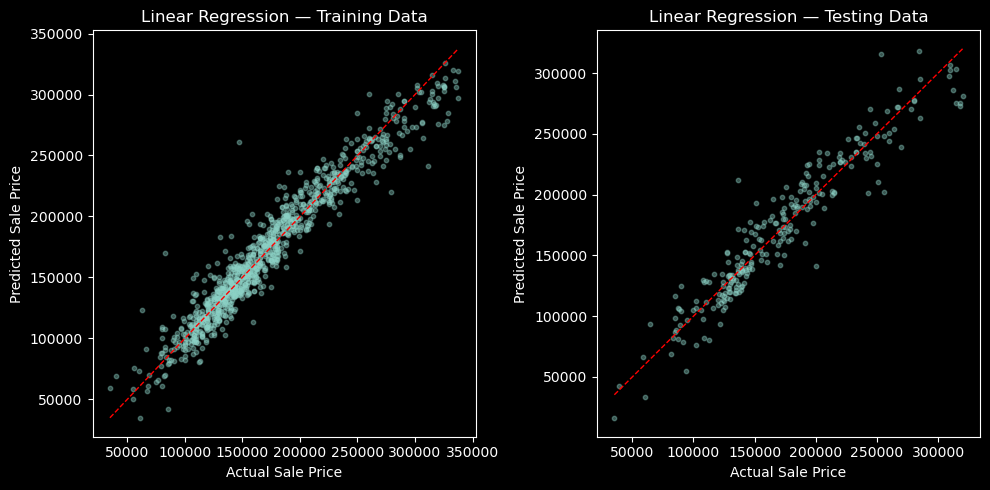

=== KNN ===
            MAE          MAPE      R^2
  Train:  $   19,135    0.120    0.786
  Test:   $   20,944    0.138    0.766


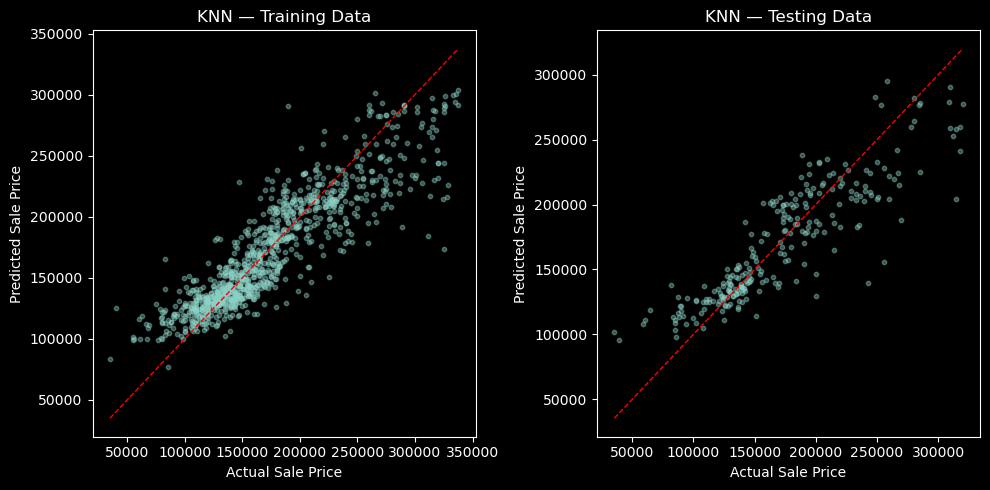

=== Decision Tree ===
            MAE          MAPE      R^2
  Train:  $    9,839    0.063    0.943
  Test:   $   19,468    0.130    0.782


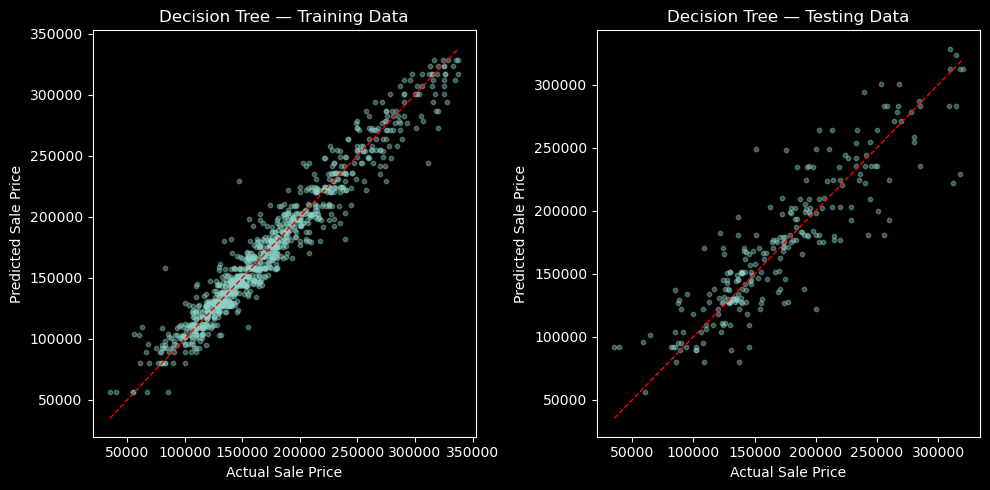

=== Random Forest ===
            MAE          MAPE      R^2
  Train:  $    7,132    0.046    0.966
  Test:   $   13,137    0.091    0.900


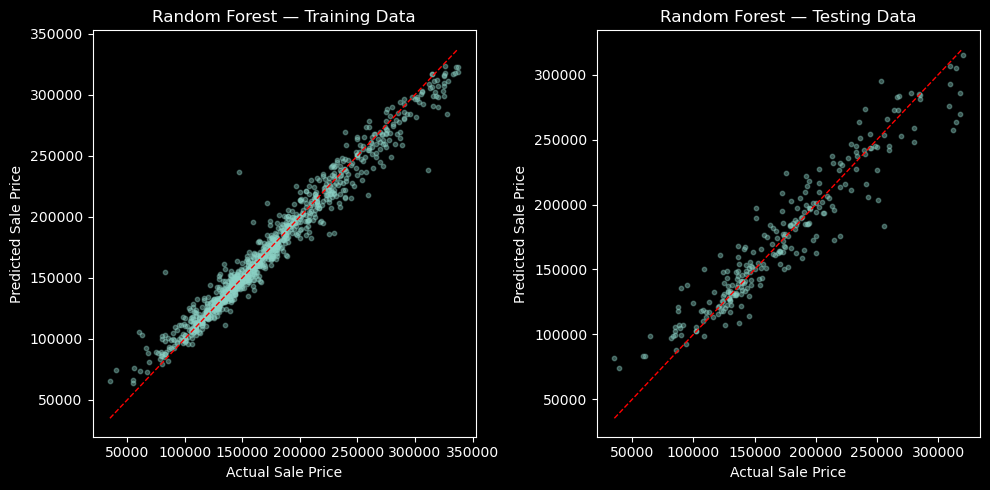

=== Gradient Boosting ===
            MAE          MAPE      R^2
  Train:  $    6,840    0.044    0.976
  Test:   $   12,166    0.079    0.914


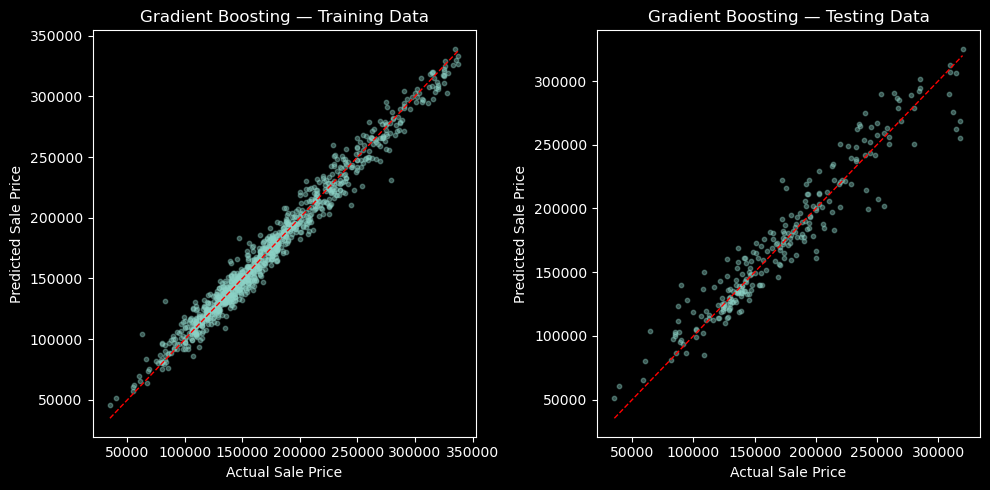

In [10]:
for name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Print this model's metrics (train / test).
    print(f"=== {name} ===")
    print("            MAE          MAPE      R^2")
    print(f"  Train:  ${mean_absolute_error(y_train, y_train_pred):>9,.0f}   "
          f"{mean_absolute_percentage_error(y_train, y_train_pred):>6.3f}   "
          f"{r2_score(y_train, y_train_pred):>6.3f}")
    print(f"  Test:   ${mean_absolute_error(y_test, y_test_pred):>9,.0f}   "
          f"{mean_absolute_percentage_error(y_test, y_test_pred):>6.3f}   "
          f"{r2_score(y_test, y_test_pred):>6.3f}")

    # Predicted vs. actual, train and test side by side.
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    for ax, yt, yp, title in [(axes[0], y_train, y_train_pred, "Training Data"),
                              (axes[1], y_test,  y_test_pred,  "Testing Data")]:
        ax.scatter(yt, yp, alpha=0.4, s=10)
        lo, hi = yt.min(), yt.max()
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
        ax.set_xlabel("Actual Sale Price")
        ax.set_ylabel("Predicted Sale Price")
        ax.set_title(f"{name} — {title}")
    plt.tight_layout()
    plt.show()

## 6. Review

- Every model family was tuned with its own grid search, then compared on identical train/test data
  using three metrics at once (MAE in dollars, MAPE as a percentage, $R^2$ as variance explained).
- **The grid searches select on MAE, not $R^2$.** $R^2$ is dimensionless — it survives any
  rescaling or shifting of the price scale untouched — so it can tell you that a model beats the
  mean-price baseline without ever telling you whether the estimate is off by \$8,000 or \$80,000.
  It is also built from *squared* errors, so it is steered by the few most expensive homes rather
  than the typical one. MAE answers in dollars and weights every home equally.
- Section 4.1 shows the consequence directly: ranking the same five models by MAE and by $R^2$
  does not produce the same order. Whichever metric you tune on is the one you are actually
  optimizing, so it should be the one that matches the decision the model supports.
- $R^2$ is still worth *reporting* — it is the fastest way to see whether a model beats predicting
  the mean at all, and it is comparable across datasets in a way dollar errors are not.
- The results table makes the trade-offs explicit, and the predicted-vs-actual plots show *how* each
  model errs, not just how much — including any train-vs-test gap that signals overfitting.

### Where next

- **Neural networks** on this same data: `U1_RealEstate-4_Keras`
- **Trimming** the 170+ features: `U1_RealEstate-5_FeatSelect`
- **Interpretability** (SHAP + fairness) on the price model: `U1_RealEstate-6_Interp`